# 01 — EDA + EVE baseline

Explores the digitized article data (see `data/README.md`) and validates the
reimplementation of EVE's estimation formula (`src/baseline.py`) against the
published predictions (table 28).

Spec: [`docs/SPEC.md`](../docs/SPEC.md).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))

by_size = pd.read_csv(DATA / "events_by_size.csv")
pre_eve = pd.read_csv(DATA / "experiment_pre_eve.csv")
exp = pd.read_csv(DATA / "experiment_eve.csv", parse_dates=["date"])
effects = pd.read_csv(DATA / "external_effects.csv", parse_dates=["date"])
by_size.head()

,size,event,invited,no_reply,maybe,confirmed,attendance
0,large,1,9824,7866,532,1426,167
1,large,2,10095,8413,252,1430,240
2,large,3,13217,12123,104,990,351
3,large,4,14860,12649,678,1533,425
4,medium,1,4321,3515,390,416,182


## 1. Conversion by size (tables 7–10)

The article's central thesis: raw RSVP does not predict attendance, and the
relationship worsens as the event grows.

In [2]:
by_size["conv_invited"] = by_size["attendance"] / by_size["invited"]
by_size["conv_confirmed"] = by_size["attendance"] / by_size["confirmed"]

order = ["micro", "small", "medium", "large"]
summary = (
    by_size.groupby("size")[["conv_invited", "conv_confirmed"]]
    .mean()
    .reindex(order)
)
summary.style.format("{:.1%}")

,conv_invited,conv_confirmed
size,,
micro,73.1%,89.5%
small,21.3%,69.5%
medium,2.5%,24.5%
large,2.4%,22.9%


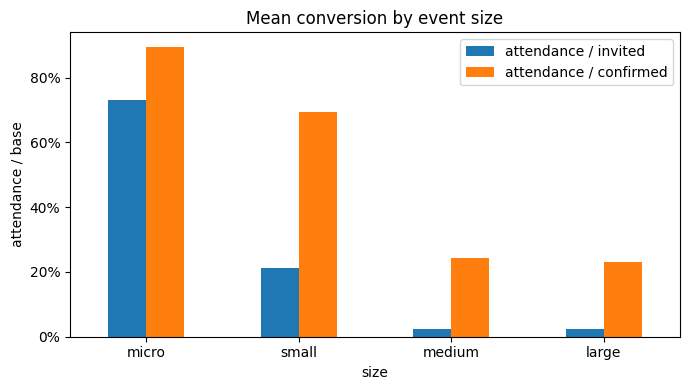

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
summary.plot.bar(ax=ax, rot=0)
ax.set_title("Mean conversion by event size")
ax.set_ylabel("attendance / base")
ax.legend(["attendance / invited", "attendance / confirmed"])
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.tight_layout()

Micro events convert ~70% of invited guests; large events ~2%. And even among
those who **confirmed**, attendance ranges from ~90% (micro) to ~15–25% (large)
— it is this conditional conversion rate that the model must learn.

## 2. Field experiment (May 2013)

Attendance per response type across the 4 rehearsals (table 25): the show-up
rate among confirmed guests rises from 45% to ~90% as the invitation list is
refined ("discovering the niche").

,confirmed,maybe,no reply
date,,,
2013-05-05,47.4%,11.8%,1.6%
2013-05-12,70.0%,44.4%,10.5%
2013-05-20,74.2%,66.7%,5.4%
2013-05-26,91.4%,50.0%,10.3%


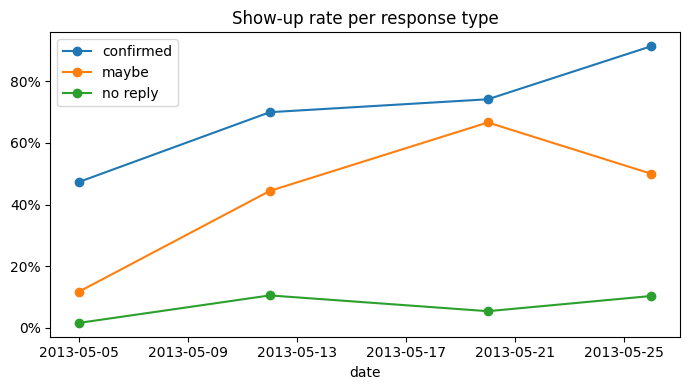

In [4]:
rates = pd.DataFrame({
    "date": exp["date"].dt.date,
    "confirmed": exp["confirmed_present"] / exp["confirmed_responses"],
    "maybe": exp["maybe_present"] / exp["maybe_responses"],
    "no reply": exp["no_reply_present"] / exp["no_reply_responses"],
}).set_index("date")

ax = rates.plot(marker="o", figsize=(7, 4))
ax.set_title("Show-up rate per response type")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.tight_layout()
rates.style.format("{:.1%}")

## 3. Baseline — EVE formula vs the article's predictions

`src/baseline.py` reimplements the formula (§4.7.8). The article has internal
arithmetic inconsistencies (documented in `data/README.md`), so the comparison
is informative, not an exact reproduction.

In [5]:
import baseline

res = pd.DataFrame(baseline.run())
res

,date,estimate,article_prediction,attendance,article_attendance
0,2013-05-05,22,21,17,17
1,2013-05-12,20,21,22,22
2,2013-05-20,29,23,29,29
3,2013-05-26,32,32,37,35


In [6]:
ours = list(zip(res["estimate"], res["attendance"]))
article = list(zip(res["article_prediction"], res["attendance"]))

comparison = pd.DataFrame(
    {
        "MAE": [baseline.mae(ours), baseline.mae(article)],
        "MAPE (%)": [baseline.mape(ours), baseline.mape(article)],
    },
    index=["our implementation", "article predictions"],
)
comparison.round(2)

,MAE,MAPE (%)
our implementation,3.0,13.00
article predictions,4.0,15.57


### Conclusions

- The clean implementation of the formula (table 27 proportions applied
  correctly) beats the article's printed predictions (MAE 3.0 vs 4.0) — on
  05-20 the article used a stale proportion.
- This is the **baseline** the learned-rates model must beat (next notebook):
  same features, no operator-supplied proportions.
- Limitation: n=4 events in the experiment + 16 by size. Next data step:
  simulation calibrated on the observed rates (see SPEC §Data).